In [55]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

# Root directory for all results
REL_PATH = "./results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000"

In [56]:
main_result_path = {
    "vanilla":
    [
        "20260115-012027_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000",
        "20260115-013345_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000",
        "20260115-012025_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000",
        "20260115-013254_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000",
    ],
    '50':
    [
        "20260116-031253_MLP_FSNet_seed0_nepochs300_lr0.0002_trainsize7000_finetune_20260116-022657_sup_seedpen_model_970",
        "20260116-034002_MLP_FSNet_seed1_nepochs300_lr0.0002_trainsize7000_finetune_20260116-022657_sup_seedpen_model_970",
        "20260116-041155_MLP_FSNet_seed2_nepochs300_lr0.0002_trainsize7000_finetune_20260116-022657_sup_seedpen_model_970",
        "20260116-043620_MLP_FSNet_seed3_nepochs300_lr0.0002_trainsize7000_finetune_20260116-022657_sup_seedpen_model_970",
    ],  # 50
    '200':
    [
        "20260116-032612_MLP_FSNet_seed0_nepochs300_lr0.0002_trainsize7000_finetune_20260116-022757_sup_seedpen_model_780",
        "20260116-035349_MLP_FSNet_seed1_nepochs300_lr0.0002_trainsize7000_finetune_20260116-022757_sup_seedpen_model_780",
        "20260116-042406_MLP_FSNet_seed2_nepochs300_lr0.0002_trainsize7000_finetune_20260116-022757_sup_seedpen_model_780",
        "20260116-044833_MLP_FSNet_seed3_nepochs300_lr0.0002_trainsize7000_finetune_20260116-022757_sup_seedpen_model_780",
    ],  # 200
    '800':
    [
        "20260116-031254_MLP_FSNet_seed0_nepochs300_lr0.0002_trainsize7000_finetune_20260116-022657_sup_seedpen_model_940",
        "20260116-034156_MLP_FSNet_seed1_nepochs300_lr0.0002_trainsize7000_finetune_20260116-022657_sup_seedpen_model_940",
        "20260116-040759_MLP_FSNet_seed2_nepochs300_lr0.0002_trainsize7000_finetune_20260116-022657_sup_seedpen_model_940",
        "20260116-043934_MLP_FSNet_seed3_nepochs300_lr0.0002_trainsize7000_finetune_20260116-022657_sup_seedpen_model_940",
    ],  # 800
    '3k':
    [
        "20260116-032722_MLP_FSNet_seed0_nepochs300_lr0.0002_trainsize7000_finetune_20260116-022847_sup_seedpen_model_920",
        "20260116-035634_MLP_FSNet_seed1_nepochs300_lr0.0002_trainsize7000_finetune_20260116-022847_sup_seedpen_model_920",
        "20260116-042343_MLP_FSNet_seed2_nepochs300_lr0.0002_trainsize7000_finetune_20260116-022847_sup_seedpen_model_920",
        "20260116-045512_MLP_FSNet_seed3_nepochs300_lr0.0002_trainsize7000_finetune_20260116-022847_sup_seedpen_model_920",
    ],  # 3000
    '10k':
    [
        "20260117-203130_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000_finetune_20260115-174154_sup_seedpen_model_900",
        "20260117-203130_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000_finetune_20260115-174154_sup_seedpen_model_900",
        "20260117-204610_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000_finetune_20260115-174154_sup_seedpen_model_900",
        "20260117-204622_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000_finetune_20260115-174154_sup_seedpen_model_900",
    ],
}

In [ ]:
def load_results_to_dict(path_dict, rel_path, batch_size=256):
    """
    Reads pickle files and returns a nested dict:
    results['Method']['MetricName'] = {'mean': float, 'std': float, 'raw': np.array}
    """
    final_metrics = {}

    # Key Mapping: Friendly Name -> Pickle File Key
    metric_map = {
        "obj_mean": "objective",
        "obj_max": "objective_max",
        "eq_violation_l1_mean": "eq_violation_l1_mean",
        "eq_violation_l1_max": "eq_violation_l1_max",
        "ineq_violation_l1_mean": "ineq_violation_l1_mean",
        "ineq_violation_l1_max": "ineq_violation_l1_max",
    }

    print(f"{'Method':<20} | {'Status'}")
    print("-" * 30)

    for method, seeds in path_dict.items():
        final_metrics[method] = {}

        # Temp storage: temp['Obj Mean'] = [val_seed0, val_seed1...]
        temp_storage = {k: [] for k in metric_map.keys()}

        for seed_dir in seeds:
            full_path = os.path.join(rel_path, seed_dir, "results.pkl")
            try:
                with open(full_path, "rb") as f:
                    data = pickle.load(f)
                    # Adjust this path based on your exact pickle structure
                    m = data['test_results']['batch_size_comparison'][batch_size]['metrics']
                    for name, key in metric_map.items():
                        temp_storage[name].append(m[key])
            except Exception as e:
                print(f"Error loading {seed_dir}: {e}")

        # Compute Mean/Std for this method across collected seeds
        n_seeds = len(seeds)
        print(f"{method:<20} | Loaded {n_seeds} seeds")

        for name, values in temp_storage.items():
            arr = np.array(values)
            final_metrics[method][name] = {
                "mean": np.mean(arr),
                "std": np.std(arr),
                "raw": arr
            }

        # 2. Retrieve raw arrays for calculation
        # Means
        r_obj_mean = final_metrics[method]["obj_mean"]["raw"]
        r_eq_mean = final_metrics[method]["eq_violation_l1_mean"]["raw"]
        r_ineq_mean = final_metrics[method]["ineq_violation_l1_mean"]["raw"]
        
        # Maxs
        r_obj_max = final_metrics[method]["obj_max"]["raw"]
        r_eq_max = final_metrics[method]["eq_violation_l1_max"]["raw"]
        r_ineq_max = final_metrics[method]["ineq_violation_l1_max"]["raw"]

        # 3. Compute Merit Mean (obj_mean + penalty * vio_mean)
        eq_weight = 1e5
        ineq_weight = 1e5
        merit_mean_raw = r_obj_mean + eq_weight * r_eq_mean + ineq_weight * r_ineq_mean
        final_metrics[method]["merit_mean"] = {
            "mean": np.mean(merit_mean_raw),
            "std": np.std(merit_mean_raw),
            "raw": merit_mean_raw
        }

        # 4. Compute Merit Max (obj_max + penalty * vio_max)
        merit_max_raw = r_obj_max + eq_weight * r_eq_max + ineq_weight * r_ineq_max
        final_metrics[method]["merit_max"] = {
            "mean": np.mean(merit_max_raw),
            "std": np.std(merit_max_raw),
            "raw": merit_max_raw
        }

    return final_metrics

# Execute Loading
metrics_data = load_results_to_dict(main_result_path, REL_PATH)

Method               | Status
------------------------------
vanilla              | Loaded 4 seeds
50                   | Loaded 4 seeds
200                  | Loaded 4 seeds
800                  | Loaded 4 seeds
3k                   | Loaded 4 seeds
10k                  | Loaded 4 seeds


In [58]:
for method, metrics in metrics_data.items():
    print(f"\nMethod: {method}")
    for metric_name, stats in metrics.items():
        print(f"  {metric_name}: Mean={stats['mean']}, Std={stats['std']}")


Method: vanilla
  obj_mean: Mean=-0.7266040012991175, Std=1.4183049112569404
  obj_max: Mean=2.459810266678275, Std=1.5315188293400754
  eq_violation_l1_mean: Mean=5.85129863111037e-05, Std=2.420320551069866e-05
  eq_violation_l1_max: Mean=0.0019293917939257896, Std=0.0011588028105687204
  ineq_violation_l1_mean: Mean=7.893000292464773e-07, Std=5.025861675356109e-07
  ineq_violation_l1_max: Mean=0.00013148525830081192, Std=0.00016169299566100813
  merit_mean: Mean=5.2036246327359, Std=3.0965579132582532
  merit_max: Mean=208.54751548933845, Std=131.7739085760266

Method: 50
  obj_mean: Mean=-2.9715378206399894, Std=0.028356339343274865
  obj_max: Mean=-0.7827297200224178, Std=0.028466070337049208
  eq_violation_l1_mean: Mean=9.795599093261287e-05, Std=3.5552706637674716e-06
  eq_violation_l1_max: Mean=0.0008261113821432855, Std=5.250452987138642e-05
  ineq_violation_l1_mean: Mean=5.164607330139248e-07, Std=4.162118877437375e-08
  ineq_violation_l1_max: Mean=2.0691358752766842e-05, Std

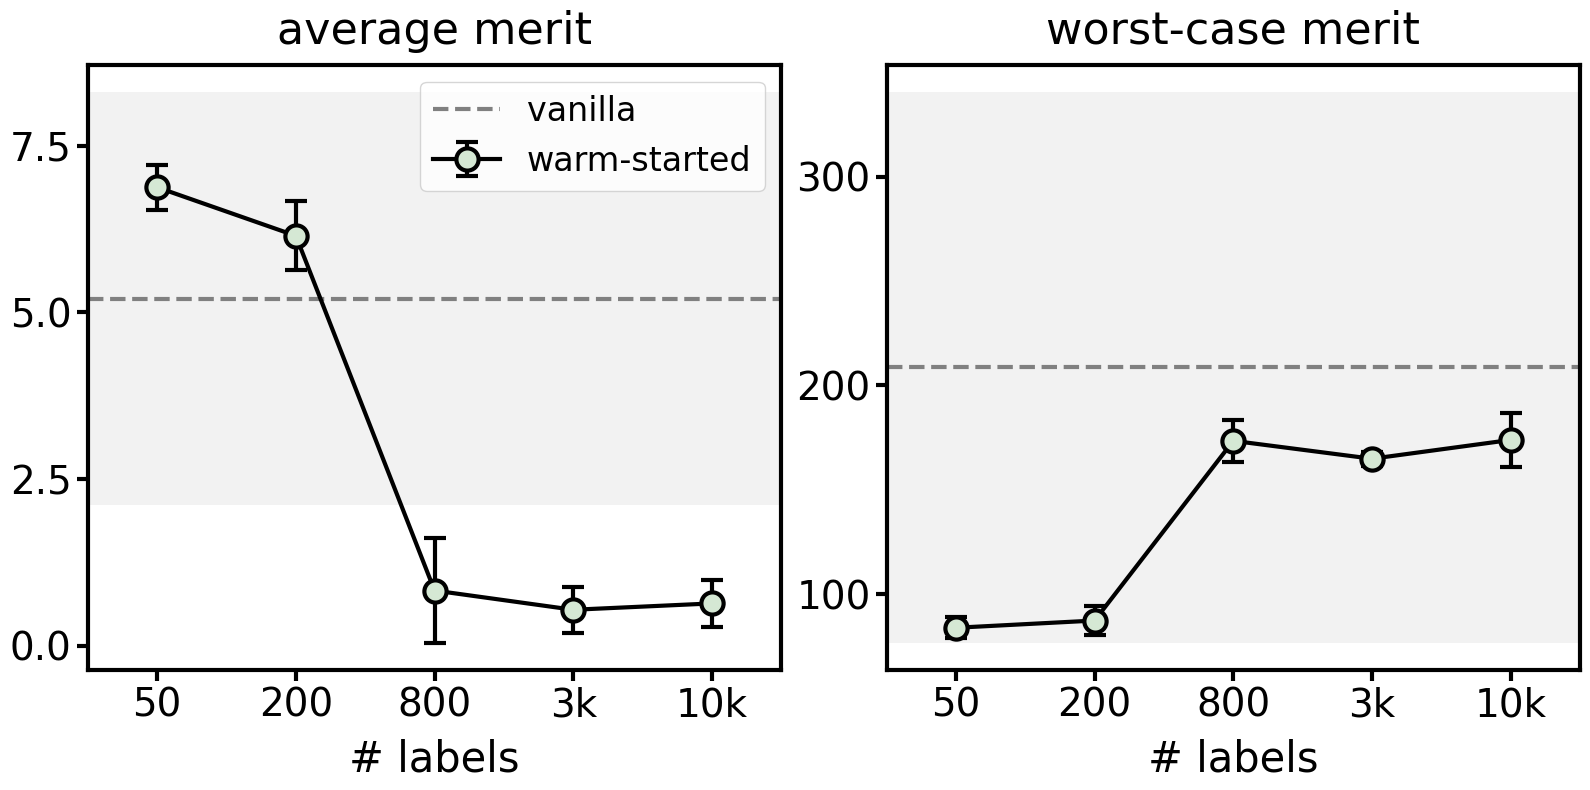

In [59]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import ScalarFormatter

def plot_merit_side_by_side_insertion_order(metrics_data):
    # 1. Setup Data using INSERTION ORDER
    # We create the list directly from keys(), filtering out 'vanilla'
    # This preserves the order: 0.5 -> 2.0 -> 3.0 -> ...
    ordered_keys = [k for k in metrics_data.keys() if k.lower() != "vanilla"]
    
    # Create uniform indices (0, 1, 2...) for equal spacing
    x_indices = np.arange(len(ordered_keys))
    
    # We keep the labels as strings exactly as they are in your dict
    x_labels = ordered_keys 
    
    mean_vals, mean_stds = [], []
    max_vals, max_stds = [], []

    for k in ordered_keys:
        mean_vals.append(metrics_data[k]['merit_mean']['mean'])
        mean_stds.append(metrics_data[k]['merit_mean']['std'])
        max_vals.append(metrics_data[k]['merit_max']['mean'])
        max_stds.append(metrics_data[k]['merit_max']['std'])

    # 2. Extract Baseline (vanilla)
    base_data = metrics_data.get("vanilla") or metrics_data.get("Vanilla") or {}
    base_mean = base_data.get("merit_mean", {}).get("mean")
    base_mean_std = base_data.get("merit_mean", {}).get("std")
    base_max = base_data.get("merit_max", {}).get("mean")
    base_max_std = base_data.get("merit_max", {}).get("std")

    # 3. Define Style Parameters
    marker_color = '#D5E8D4'  
    baseline_color = 'gray'
    line_color = 'black'
    line_width = 3
    marker_size = 16
    cap_size = 8

    # 4. Create Subplots
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    def plot_on_axis(ax, y_data, y_err, title, baseline_val, baseline_std):
        # Plot using the index (0, 1, 2...)
        ax.errorbar(x_indices, y_data, yerr=y_err, fmt='-o', 
                    color=line_color, linewidth=line_width, 
                    markerfacecolor=marker_color, markeredgecolor=line_color,
                    markeredgewidth=line_width, markersize=marker_size,
                    capsize=cap_size, elinewidth=line_width, capthick=line_width,
                    label='warm-started')

        if baseline_val is not None:
            ax.axhline(y=baseline_val, color=baseline_color, linestyle='--', 
                       linewidth=line_width, label='vanilla')
            if baseline_std is not None:
                ax.axhspan(baseline_val - baseline_std, baseline_val + baseline_std, 
                           color=baseline_color, alpha=0.1, lw=0)

        for spine in ax.spines.values():
            spine.set_linewidth(line_width)
            spine.set_color('black')

        # Set the labels using your custom strings
        ax.set_xticks(x_indices)
        ax.set_xticklabels(x_labels, fontsize=28, fontweight='normal')
        
        # Add padding
        ax.set_xlim(x_indices[0] - 0.5, x_indices[-1] + 0.5)

        ax.tick_params(axis='y', labelsize=28, width=line_width, length=8, color='black')
        ax.tick_params(axis='x', width=line_width, length=8, color='black')
        ax.minorticks_off()
        
        ax.set_xlabel('# labels', fontsize=30, labelpad=10)
        ax.set_title(title, fontsize=32, pad=15)
        ax.set_facecolor("white")
        ax.locator_params(axis='y', nbins=4)
        
        if title == "average merit":
             ax.legend(fontsize=24, loc='best', frameon=True)

    plot_on_axis(axes[0], mean_vals, mean_stds, "average merit", base_mean, base_mean_std)
    plot_on_axis(axes[1], max_vals, max_stds, "worst-case merit", base_max, base_max_std)

    plt.tight_layout()
    plt.show()

# Run
plot_merit_side_by_side_insertion_order(metrics_data)